In [28]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk

In [29]:
choice = 2  #start from 0
devices = ['nmos4', 'pmos4','nmos_xh018','pmos_xh018']
fet = lk('../lookup_table/018/'+devices[choice]+'.mat')

In [30]:
# sweep variable vectors
l = fet['L']
vgs = fet['VGS']
vds = fet['VDS']
vsb = fet['VSB']

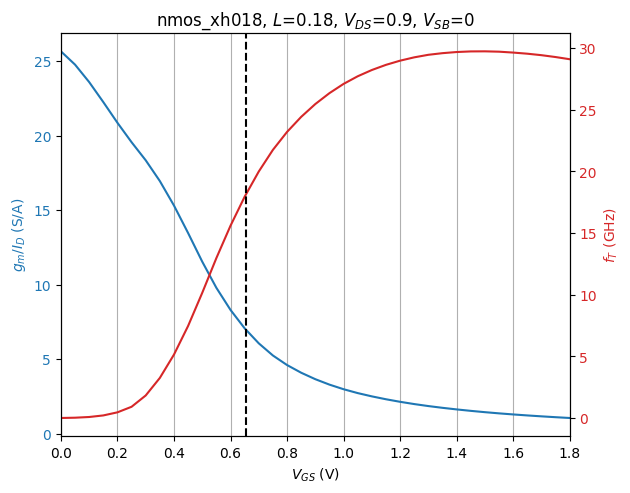

In [31]:
# plot gm/ID and fT versus gate bias
L1 = min(l); VDS1=0.9; VSB1=0
VGS = np.linspace(0.35,1.8,37)
gm_id1 = fet.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1, VGS = VGS)
ft1 = fet.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1, VGS = VGS)/2/np.pi
vt = fet.lookup('VT', L=L1, VGS=0.9, VDS=VDS1, VSB=VSB1)

fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id1, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft1/1e9, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, 1.8)
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

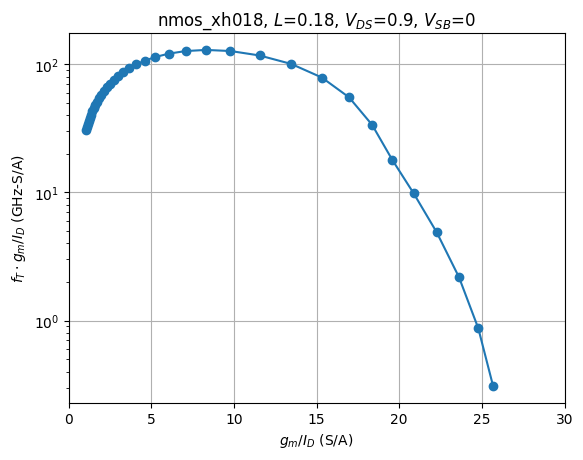

In [32]:
# plot product of gm/ID ant fT versus gm/ID
plt.semilogy(gm_id1, gm_id1*ft1/1e9,marker='o')
plt.xlim(0, 30)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$f_T\cdot g_m/I_D$ (GHz-S/A)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

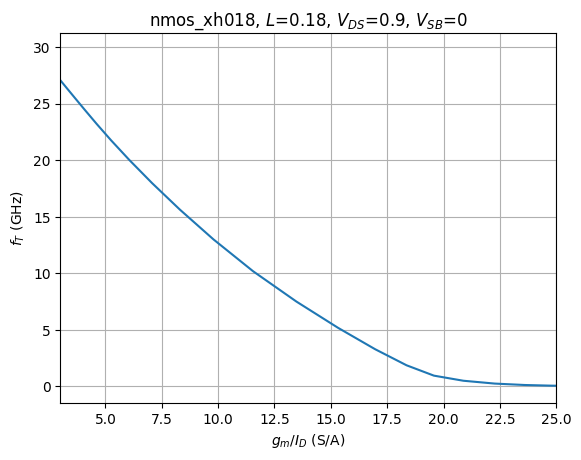

In [33]:
# plot fT versus gm/ID
plt.plot(gm_id1, ft1/1e9)
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$f_T$ (GHz)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

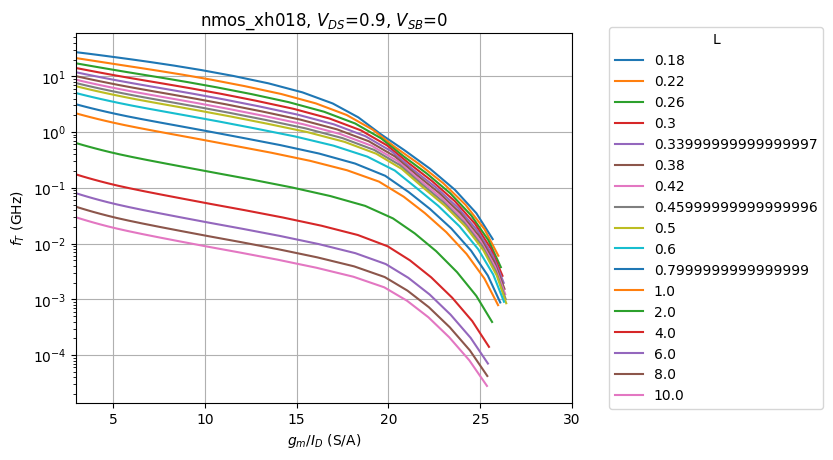

In [34]:
# plot fT versus gm/ID for all L
VDS2=0.9; VSB2=0
gm_id2 = fet.lookup('GM_ID', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)
ft2 = fet.lookup('GM_CGG', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)/2/np.pi

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), ft2.transpose()/1e9)
ax.legend(loc='center right', bbox_to_anchor=(1.52, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 30)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$f_T$ (GHz)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

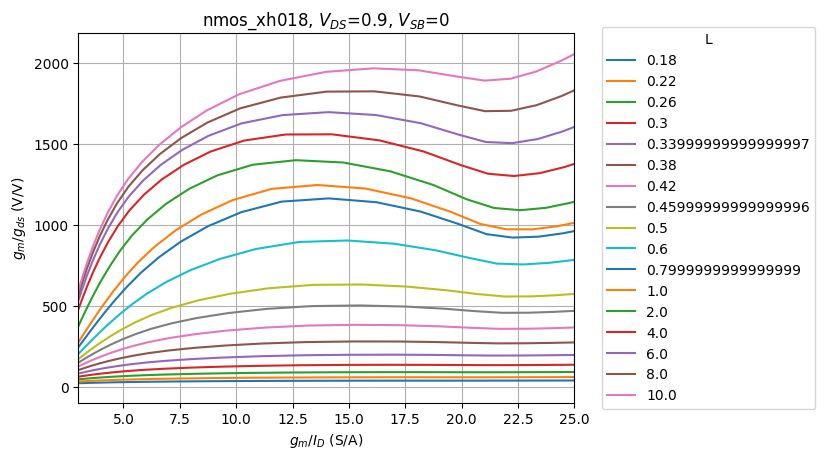

In [35]:
# plot gm/gds versus gm/ID for all L
gm_gds2 = fet.lookup('GM_GDS', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)

fig, ax = plt.subplots()
ax.plot(gm_id2.transpose(), gm_gds2.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$g_m/g_{ds}$ (V/V)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

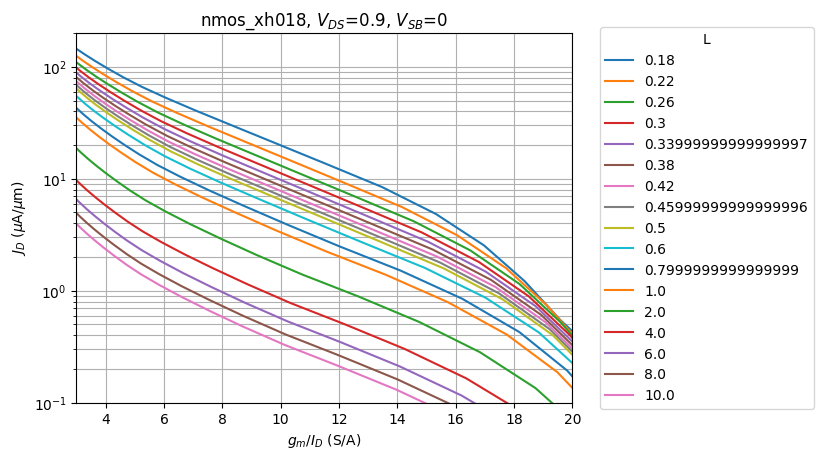

In [36]:
# plot jd versus gm/ID for all L
jd2 = fet.lookup('ID_W', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)/1e-6

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), jd2.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.1, 200)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$J_D$ ($\mu$A/$\mu$m)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

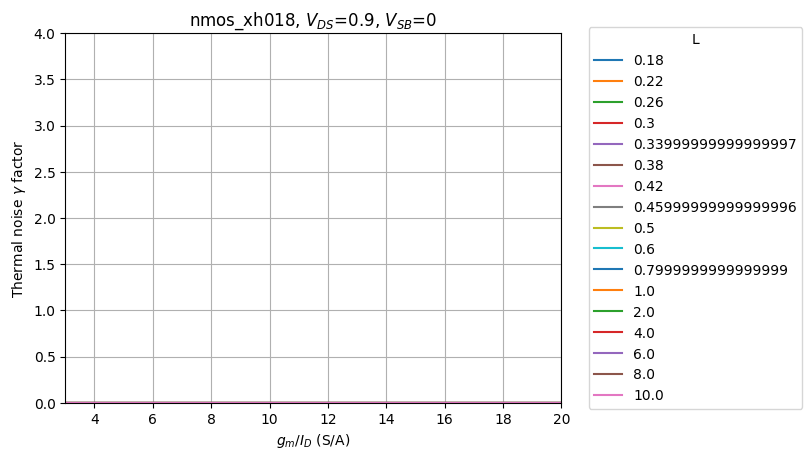

[[1.52271798e-28 5.81737125e-28 2.32263134e-27 9.50741377e-27
  3.70085499e-26 1.16215852e-25 4.94769615e-25 1.88067269e-24
  5.03247013e-24 1.01917810e-23 1.72033689e-23 2.56335391e-23
  3.51132481e-23 4.56031942e-23 5.71446417e-23 6.97683005e-23
  8.36573896e-23 9.86690889e-23 1.14635160e-22 1.31530335e-22
  1.49295966e-22 1.67841954e-22 1.87458361e-22 2.07637458e-22
  2.28393028e-22 2.49777027e-22 2.71829274e-22 2.94256823e-22
  3.16913253e-22 3.39938310e-22 3.63329025e-22 3.86809175e-22
  4.10724965e-22 4.34611753e-22 4.58431320e-22 4.82163636e-22
  5.05790930e-22]
 [1.13779198e-28 4.23877158e-28 1.63532215e-27 6.44644660e-27
  2.43119639e-26 7.49970028e-26 3.12394835e-25 1.18598619e-24
  3.21578505e-24 6.59123855e-24 1.12358933e-23 1.67823228e-23
  2.29620481e-23 2.97466781e-23 3.71559259e-23 4.52011334e-23
  5.39701801e-23 6.34399969e-23 7.34659354e-23 8.40412536e-23
  9.51590896e-23 1.06823995e-22 1.19037244e-22 1.31692487e-22
  1.44777312e-22 1.58252387e-22 1.72034948e-22 1.862

In [37]:
# plot gamma versus gm/ID for all L
gamma = fet.lookup('STH_GM', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS) / (4*sc.Boltzmann*300)
fig, ax = plt.subplots()
ax.plot(gm_id2.transpose(), gamma.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0, 4)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'Thermal noise $\gamma$ factor')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

print(gamma)

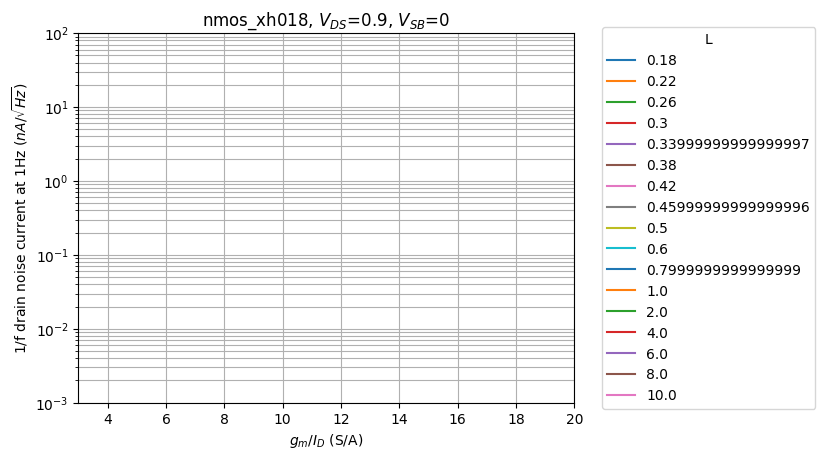

In [38]:
# plot flicker noise drain current at 1Hz versus gm/ID for all L
sfl = fet.lookup('SFL', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)**0.5

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), sfl.transpose()/1e-9)
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.001, 100)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'1/f drain noise current at 1Hz ($nA/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

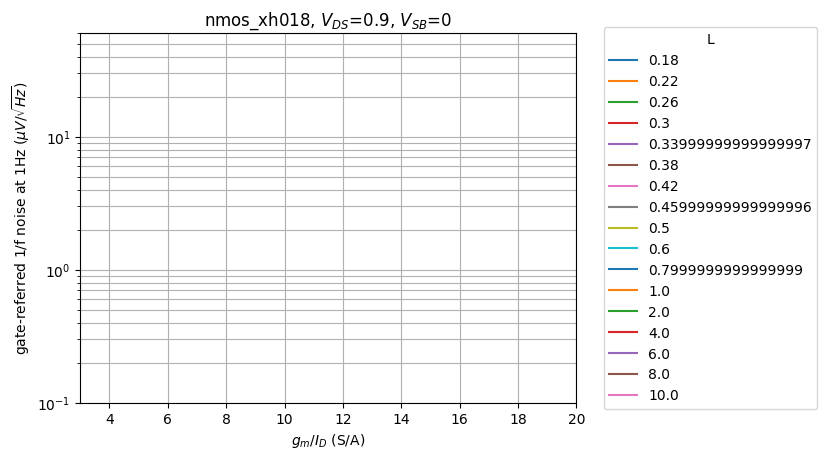

In [39]:
# plot gate-referred 1/f noise at 1Hz versus gm/ID for all L
sfl_gate = fet.lookup('SFL', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)**0.5 / fet.lookup('GM', L=l, VDS=VDS1, VSB=VSB1)

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), sfl_gate.transpose()/1e-6)
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.1, 60)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'gate-referred 1/f noise at 1Hz ($\mu V/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()